In [1]:
import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt
import scipy
from sandbox.jordan5 import setup_device
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from sandbox.jordan8 import *

import json

In [2]:
device = setup_device()

torch.manual_seed(0)
np.random.seed(0)

# Training from scratch

In [3]:
model = JordanNet(encode_dim=32)

training_dimensions = [4, 8, 12]
for d in training_dimensions:
    model.add_dimension(d)

training_dataset = generate_training_datasets(matrices_per_class=2000,
                                              dimensions=[4, 8, 12])

model = train_jordan_net(
    model,
    training_dataset,
    num_epochs=50, 
    batch_size=64,
    lr=1e-3,
    device=device,
    train_transformer=True,
    patience=3,
)

Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Generating class with d=8, max_block_size=1...Done.
Generating class with d=8, max_block_size=2...Done.
Generating class with d=8, max_block_size=3...Done.
Generating class with d=8, max_block_size=4...Done.
Generating class with d=8, max_block_size=5...Done.
Generating class with d=8, max_block_size=6...Done.
Generating class with d=8, max_block_size=7...Done.
Generating class with d=8, max_block_size=8...Done.
Generating class with d=12, max_block_size=1...Done.
Generating class with d=12, max_block_size=2...Done.
Generating class with d=12, max_block_size=3...Done.
Generating class with d=12, max_block_size=4...Done.
Generating class with d=12, max_block_size=5...Done.
Generating class with d=12, max_block_size=6...Done.
Generating class with d=12, max_block_size=7...Done.
Gener

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/50] | Train Loss: 0.881224 | Val Loss: 0.691476
Epoch [2/50] | Train Loss: 0.641317 | Val Loss: 0.614993
Epoch [3/50] | Train Loss: 0.585399 | Val Loss: 0.565107
Epoch [4/50] | Train Loss: 0.533666 | Val Loss: 0.510754
Epoch [5/50] | Train Loss: 0.488305 | Val Loss: 0.485025
Epoch [6/50] | Train Loss: 0.459078 | Val Loss: 0.518601
Epoch [7/50] | Train Loss: 0.426037 | Val Loss: 0.416619
Epoch [8/50] | Train Loss: 0.399239 | Val Loss: 0.397882
Epoch [9/50] | Train Loss: 0.378123 | Val Loss: 0.374189
Epoch [10/50] | Train Loss: 0.362601 | Val Loss: 0.357908
Epoch [11/50] | Train Loss: 0.343771 | Val Loss: 0.339308
Epoch [12/50] | Train Loss: 0.326525 | Val Loss: 0.326753
Epoch [13/50] | Train Loss: 0.317413 | Val Loss: 0.323956
Epoch [14/50] | Train Loss: 0.311641 | Val Loss: 0.318956
Epoch [15/50] | Train Loss: 0.300366 | Val Loss: 0.327068
Epoch [16/50] | Train Loss: 0.295741 | Val Loss: 0.311521
Epoch [17/50] | Train Loss: 0.284214 | Val Loss: 0.304062
Epoch [18/50] | Train L

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:431: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8_{d}

# Tests

In [6]:
def run_test(model, d, matrices_per_class=1000, mode="random", eps=None, eps_range=None):
    model.eval()

    training_dataset = generate_training_datasets(
        matrices_per_class=matrices_per_class,
        dimensions=[d],
        mode=mode,
        eps=eps,
        eps_range=eps_range,
        device="cpu",
    )
    matrices, labels, features, masks, dists = training_dataset[d]
    loader = DataLoader(TensorDataset(features, labels, masks, dists), batch_size=64, shuffle=False)

    predicted_classes = []
    true_classes = labels.cpu().tolist()
    kl_avg = 0.0

    for batch_features, batch_labels, batch_masks, batch_dists in loader:
        batch_features = batch_features.to(device)
        batch_labels = batch_labels.to(device)
        batch_masks = batch_masks.to(device)
        batch_dists = batch_dists.to(device)

        logits = model(d, batch_features, masks=batch_masks)
        loss = kl_loss(logits, batch_dists)

        preds = torch.argmax(logits, dim=-1)
        predicted_classes += preds.cpu().tolist()
        kl_avg += loss.item() * batch_features.size(0)

    kl_avg /= len(loader.dataset)
    # print(f"Test KL Loss: {kl_avg:.6f}")

    return true_classes, predicted_classes, kl_avg

def test_jordan_net(model, d, matrices_per_class=1000, filename=None):
    if filename is None:
        filename = f"sandbox/jordan8_results/results_{d}.json"

    results = []

    for eps in [0.0, 1e-6, 1e-4, 1e-2, 1e-1, 1]:
        print(f"Testing with eps={eps}")
        true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="random", eps=eps)
        results.append({
            "eps": eps,
            "true_classes": true_classes,
            "predicted_classes": predicted_classes,
            "kl_avg": kl_avg,
        })
    
    print(f"Testing mode 'ortho'")
    true_classes, predicted_classes, kl_avg = run_test(model, d, matrices_per_class=matrices_per_class, mode="ortho", eps=0.0)
    results.append({
        "eps": "ortho",
        "true_classes": true_classes,
        "predicted_classes": predicted_classes,
        "kl_avg": kl_avg,
    })
    with open(filename, "w") as f:
        json.dump(results, f, indent=4)
    
def visualize_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f) 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(1, d+1)))
        disp.plot(cmap=plt.cm.Blues)
        title = f"{'eps='+str(eps) if eps != 'ortho' else 'ortho'}. KL Loss: {result['kl_avg']:.6f}, accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        plt.title(title)
        plt.show()
    
def print_test_results(d, filename):
    with open(filename, "r") as f:
        results = json.load(f)

    print(f"\nTest results for dimension {d}:") 
    
    for result in results:
        eps = result["eps"]
        true_classes = result["true_classes"]
        predicted_classes = result["predicted_classes"]
        
        cm = confusion_matrix(true_classes, predicted_classes, labels=list(range(d)))
        title = f"\t{'eps='+f'{eps:<10}' if eps != 'ortho' else 'ortho     '}\t KL Loss: {result['kl_avg']:.6f},\t accuracy: {np.trace(cm) / np.sum(cm):.4f}"
        print(title)

In [29]:
model = JordanNet(encode_dim=32)
training_dimensions = [4, 8, 12]
for d in training_dimensions:
    model.add_dimension(d)
model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"))
model.to(device)
for d in training_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=4, max_block_size=1...

C:\Users\micha\AppData\Local\Temp\ipykernel_12012\402474283.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=1e-06
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.0001
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.01
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class with d=4, max_block_size=3...Done.
Generating class with d=4, max_block_size=4...Done.
Testing with eps=0.1
Generating class with d=4, max_block_size=1...Done.
Generating class with d=4, max_block_size=2...Done.
Generating class wit

In [30]:
for d in training_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")


Test results for dimension 4:
	eps=0.0       	 KL Loss: 0.069732,	 accuracy: 1.0000
	eps=1e-06     	 KL Loss: 0.018614,	 accuracy: 0.9998
	eps=0.0001    	 KL Loss: 0.431513,	 accuracy: 0.9980
	eps=0.01      	 KL Loss: 0.462282,	 accuracy: 0.8405
	eps=0.1       	 KL Loss: 1.327171,	 accuracy: 0.2657
	eps=1         	 KL Loss: 2.078857,	 accuracy: 0.2500
	ortho     	 KL Loss: 0.068392,	 accuracy: 1.0000

Test results for dimension 8:
	eps=0.0       	 KL Loss: 0.108662,	 accuracy: 0.9950
	eps=1e-06     	 KL Loss: 0.026504,	 accuracy: 0.9980
	eps=0.0001    	 KL Loss: 0.476524,	 accuracy: 0.9954
	eps=0.01      	 KL Loss: 0.710368,	 accuracy: 0.6881
	eps=0.1       	 KL Loss: 6.825666,	 accuracy: 0.1411
	eps=1         	 KL Loss: 1.913599,	 accuracy: 0.1254
	ortho     	 KL Loss: 0.126251,	 accuracy: 0.9885

Test results for dimension 12:
	eps=0.0       	 KL Loss: 0.215914,	 accuracy: 0.9943
	eps=1e-06     	 KL Loss: 0.035022,	 accuracy: 0.9976
	eps=0.0001    	 KL Loss: 0.340312,	 accuracy: 0.8

# Training + tests on additional dimensions

In [3]:
model = JordanNet(encode_dim=32).cpu()
pretrained_dimensions = [4, 8, 12]
for d in pretrained_dimensions:
    model.add_dimension(d)

model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth", map_location="cpu"))
model.to(device)

new_dimensions = [13]

for d in new_dimensions:
    model.add_dimension(d)
    training_dataset = generate_training_datasets(matrices_per_class=400,
                                                dimensions=[d])
    print(training_dataset)
    model = train_jordan_net(
        model,
        training_dataset,
        num_epochs=50,
        batch_size=64,
        lr=1e-3,
        device=device,
        train_transformer=False)

Generating class with d=13, max_block_size=1...Done.
Generating class with d=13, max_block_size=2...

C:\Users\micha\AppData\Local\Temp\ipykernel_11172\940656409.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f"sandbox/model_jordan8.pth"

Done.
Generating class with d=13, max_block_size=3...Done.
Generating class with d=13, max_block_size=4...Done.
Generating class with d=13, max_block_size=5...Done.
Generating class with d=13, max_block_size=6...Done.
Generating class with d=13, max_block_size=7...Done.
Generating class with d=13, max_block_size=8...Done.
Generating class with d=13, max_block_size=9...Done.
Generating class with d=13, max_block_size=10...Done.
Generating class with d=13, max_block_size=11...Done.
Generating class with d=13, max_block_size=12...Done.
Generating class with d=13, max_block_size=13...Done.
{13: (tensor([[[ 7.4841e-06, -1.2002e-06,  2.9902e-06,  ..., -2.0878e-06,
          -9.9362e-06, -9.1068e-07],
         [-1.1324e-05,  4.7233e-06, -5.9302e-06,  ...,  6.2064e-06,
           1.7342e-05,  2.0873e-06],
         [ 1.2369e-05, -4.6182e-06,  1.1559e-05,  ..., -6.7310e-06,
          -1.8758e-05, -4.1576e-06],
         ...,
         [-2.1616e-06, -2.2042e-06,  1.1146e-06,  ...,  3.1354e-06,
    

c:\Users\micha\Documents\Studia\Magisterka\venv\Lib\site-packages\torch\nn\functional.py:3006: UserWarning: The operator 'aten::xlogy.OutTensor' is not currently supported on the DML backend and will fall back to run on the CPU. This may have performance implications. (Triggered internally at C:\__w\1\s\pytorch-directml-plugin\torch_directml\csrc\dml\dml_cpu_fallback.cpp:17.)
  reduced = torch.kl_div(input, target, reduction_enum, log_target=log_target)


Epoch [1/50] | Train Loss: 1.962893 | Val Loss: 1.457762
Epoch [2/50] | Train Loss: 1.259177 | Val Loss: 1.059117
Epoch [3/50] | Train Loss: 1.034403 | Val Loss: 0.947078
Epoch [4/50] | Train Loss: 0.957517 | Val Loss: 0.894131
Epoch [5/50] | Train Loss: 0.910991 | Val Loss: 0.867320
Epoch [6/50] | Train Loss: 0.872319 | Val Loss: 0.848712
Epoch [7/50] | Train Loss: 0.846312 | Val Loss: 0.809786
Epoch [8/50] | Train Loss: 0.818852 | Val Loss: 0.811463
Epoch [9/50] | Train Loss: 0.794756 | Val Loss: 0.777795
Epoch [10/50] | Train Loss: 0.772306 | Val Loss: 0.752428
Epoch [11/50] | Train Loss: 0.748628 | Val Loss: 0.730959
Epoch [12/50] | Train Loss: 0.732355 | Val Loss: 0.726241
Epoch [13/50] | Train Loss: 0.709539 | Val Loss: 0.691564
Epoch [14/50] | Train Loss: 0.693712 | Val Loss: 0.682105
Epoch [15/50] | Train Loss: 0.669051 | Val Loss: 0.682070
Epoch [16/50] | Train Loss: 0.651180 | Val Loss: 0.650027
Epoch [17/50] | Train Loss: 0.642074 | Val Loss: 0.628070
Epoch [18/50] | Train L

c:\Users\micha\Documents\Studia\Magisterka\sandbox\jordan8.py:434: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(filename))


In [7]:
for d in new_dimensions:
    test_jordan_net(model, d, matrices_per_class=1000)

Testing with eps=0.0
Generating class with d=13, max_block_size=1...Done.
Generating class with d=13, max_block_size=2...Done.
Generating class with d=13, max_block_size=3...Done.
Generating class with d=13, max_block_size=4...Done.
Generating class with d=13, max_block_size=5...Done.
Generating class with d=13, max_block_size=6...Done.
Generating class with d=13, max_block_size=7...Done.
Generating class with d=13, max_block_size=8...Done.
Generating class with d=13, max_block_size=9...Done.
Generating class with d=13, max_block_size=10...Done.
Generating class with d=13, max_block_size=11...Done.
Generating class with d=13, max_block_size=12...Done.
Generating class with d=13, max_block_size=13...Done.
Testing with eps=1e-06
Generating class with d=13, max_block_size=1...Done.
Generating class with d=13, max_block_size=2...Done.
Generating class with d=13, max_block_size=3...Done.
Generating class with d=13, max_block_size=4...Done.
Generating class with d=13, max_block_size=5...Done

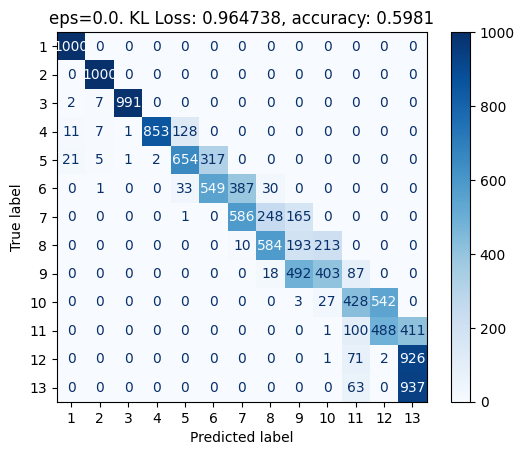

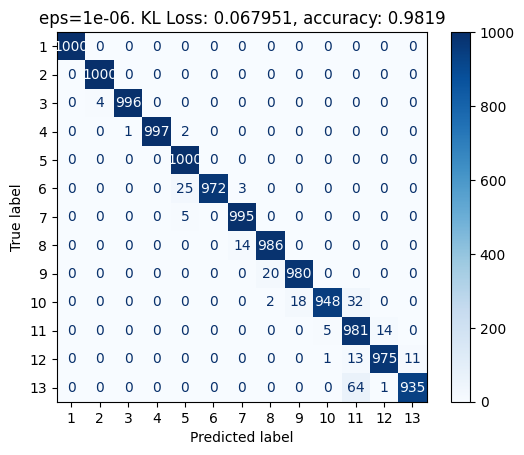

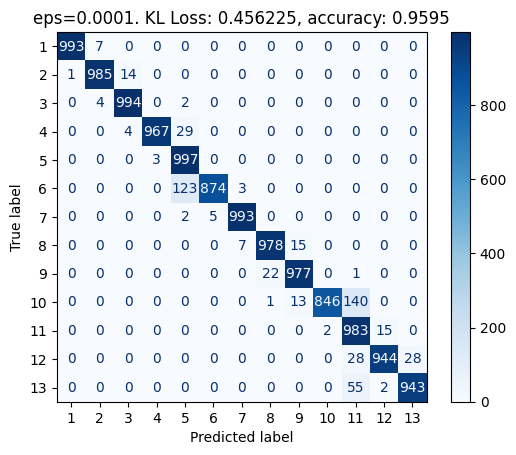

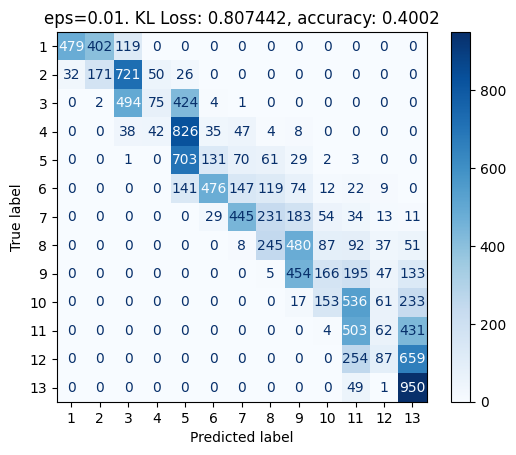

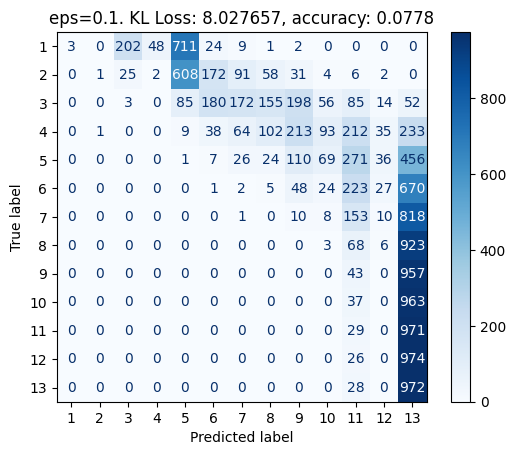

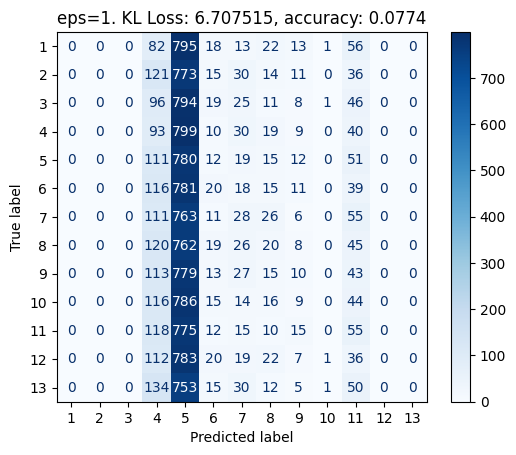

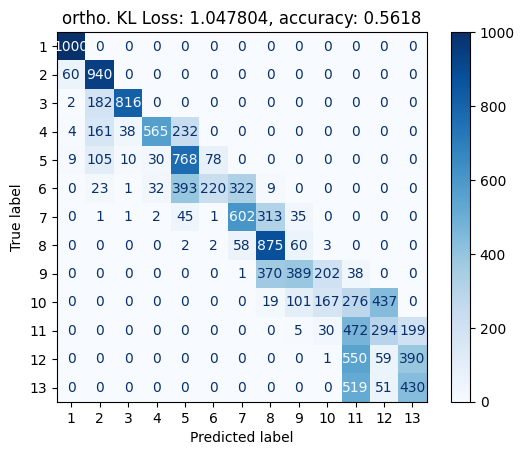

In [ ]:
for d in new_dimensions:
    print_test_results(d, f"sandbox/jordan8_results/results_{d}.json")

In [ ]:
visualize_test_results(d, f"sandbox/jordan8_results/results_28.json")